In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Data Overview

In [116]:
df = pd.read_csv('../data/raw_data.csv')
df.head()

,order_id,customer_id,order_status,customer_state,price,freight_value,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,...,payment_value,customer_lat,customer_lng,seller_lat,seller_lng,delivery_time_days,approval_hours,carrier_handover_hours,purchase_month,purchase_dayofweek
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,SP,29.99,8.72,4.0,500.0,19.0,8.0,...,18.12,-23.576983,-46.587161,-23.680729,-46.444238,15,0.178333,56.795833,10,0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,SP,29.99,8.72,4.0,500.0,19.0,8.0,...,2.00,-23.576983,-46.587161,-23.680729,-46.444238,15,0.178333,56.795833,10,0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,SP,29.99,8.72,4.0,500.0,19.0,8.0,...,18.59,-23.576983,-46.587161,-23.680729,-46.444238,15,0.178333,56.795833,10,0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,BA,118.70,22.76,1.0,400.0,19.0,13.0,...,141.46,-12.177924,-44.660711,-19.807681,-43.980427,19,30.713889,11.109167,7,1
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,GO,159.90,19.22,1.0,420.0,24.0,19.0,...,179.12,-16.745150,-48.514783,-21.363502,-48.229601,26,0.276111,4.910278,8,2


In [117]:
# Check the columns of the data
print(f"Columns in the dataset: {df.columns.tolist()}")

Columns in the dataset: ['order_id', 'customer_id', 'order_status', 'customer_state', 'price', 'freight_value', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_state', 'payment_type', 'payment_installments', 'payment_value', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'delivery_time_days', 'approval_hours', 'carrier_handover_hours', 'purchase_month', 'purchase_dayofweek']


In [118]:
# Check the shape of the data
print(f"The data has {df.shape[0]} rows and {df.shape[1]} columns.")

The data has 118434 rows and 25 columns.


In [119]:
df.dtypes

order_id                             str
customer_id                          str
order_status                         str
customer_state                       str
price                            float64
freight_value                    float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english        str
seller_state                         str
payment_type                         str
payment_installments             float64
payment_value                    float64
customer_lat                     float64
customer_lng                     float64
seller_lat                       float64
seller_lng                       float64
delivery_time_days                 int64
approval_hours                   float64
carrier_handover_hours           float64
purchase_month                     int64
purchase_dayofwe

In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  str    
 1   customer_id                    118434 non-null  str    
 2   order_status                   118434 non-null  str    
 3   customer_state                 118434 non-null  str    
 4   price                          118434 non-null  float64
 5   freight_value                  118434 non-null  float64
 6   product_photos_qty             118434 non-null  float64
 7   product_weight_g               118434 non-null  float64
 8   product_length_cm              118434 non-null  float64
 9   product_height_cm              118434 non-null  float64
 10  product_width_cm               118434 non-null  float64
 11  product_category_name_english  118434 non-null  str    
 12  seller_state                   118434 non

In [121]:
df.describe()

,price,freight_value,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_installments,payment_value,customer_lat,customer_lng,seller_lat,seller_lng,delivery_time_days,approval_hours,carrier_handover_hours,purchase_month,purchase_dayofweek
count,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000,118434.000000
mean,120.501016,20.019232,2.182068,2104.130782,30.219143,16.604235,23.046372,2.937374,172.847757,-21.231860,-46.191598,-22.800118,-47.231400,23.490729,10.564758,68.079724,6.033723,2.745056
std,183.869718,15.808778,1.710003,3777.020723,16.138769,13.413897,11.709002,2.774133,268.256631,5.560711,4.039090,2.683237,2.330616,8.871672,25.979113,85.572034,3.231805,1.960629
min,0.850000,0.000000,1.000000,0.000000,7.000000,2.000000,6.000000,0.000000,0.000000,-33.689948,-72.668881,-32.079231,-67.813284,1.000000,0.000000,-4109.256111,1.000000,0.000000
25%,39.900000,13.080000,1.000000,300.000000,18.000000,8.000000,15.000000,1.000000,60.860000,-23.589378,-48.078738,-23.605514,-48.829744,18.000000,0.215833,21.550000,3.000000,1.000000
50%,74.900000,16.290000,1.000000,700.000000,25.000000,13.000000,20.000000,2.000000,108.200000,-22.928413,-46.631239,-23.425556,-46.748071,23.000000,0.346944,44.305000,6.000000,3.000000
75%,133.000000,21.150000,3.000000,1800.000000,38.000000,20.000000,30.000000,4.000000,189.240000,-20.199186,-43.624737,-21.757321,-46.522287,28.000000,14.973056,86.135694,8.000000,4.000000
max,6735.000000,409.680000,20.000000,40425.000000,105.000000,105.000000,118.000000,24.000000,13664.080000,42.184003,-8.723762,-2.501242,-34.855616,155.000000,4509.180556,3018.301667,12.000000,6.000000


In [122]:
# Check for duplicate values in the data
df.duplicated().sum()

np.int64(11440)

In [123]:
# Display the duplicate rows
duplicates = df[df.duplicated()]
duplicates.head()

,order_id,customer_id,order_status,customer_state,price,freight_value,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,...,payment_value,customer_lat,customer_lng,seller_lat,seller_lng,delivery_time_days,approval_hours,carrier_handover_hours,purchase_month,purchase_dayofweek
14,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,RJ,99.00,30.53,1.0,9000.0,42.0,12.0,...,259.06,-22.896463,-43.272172,-20.278513,-40.411675,21,0.152222,39.839444,5,1
60,9faeb9b2746b9d7526aef5acb08e2aa0,79183cd650e2bb0d475b0067d45946ac,delivered,RS,60.00,15.52,2.0,100.0,20.0,11.0,...,151.04,-30.049925,-51.201923,-23.661305,-46.564296,20,0.253056,21.147222,7,3
66,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,SE,22.99,22.85,1.0,150.0,19.0,4.0,...,91.68,-10.971622,-37.067341,-23.580395,-46.591326,23,0.840000,128.844444,3,4
76,f271576bed568e896f99eb710cd3a6f8,5dda11942d4f77bee3a46d71e442aec4,delivered,BA,329.90,82.48,1.0,10000.0,30.0,20.0,...,824.76,-12.709313,-41.830256,-25.448219,-49.254297,37,0.109444,72.078056,1,6
79,68e48e68da1f50f7c5838ea75e3a20dd,4afc1dcca5fe8926fc97d60a4497f8ab,delivered,SP,84.90,13.25,1.0,150.0,16.0,6.0,...,392.60,-23.537410,-46.466583,-22.353827,-49.101471,24,0.976111,22.900833,6,0


In [124]:
# Drop duplicate rows
print("Before dropping duplicates:", df.shape)
df = df.drop_duplicates()
print("After dropping duplicates:", df.shape)

Before dropping duplicates: (118434, 25)
After dropping duplicates: (106994, 25)


In [125]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [126]:
# Check for missing values
df.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
customer_state                   0
price                            0
freight_value                    0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
seller_state                     0
payment_type                     0
payment_installments             0
payment_value                    0
customer_lat                     0
customer_lng                     0
seller_lat                       0
seller_lng                       0
delivery_time_days               0
approval_hours                   0
carrier_handover_hours           0
purchase_month                   0
purchase_dayofweek               0
dtype: int64

In [127]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'str']).columns

print(f"The data has {len(numerical_cols)} numerical columns: {numerical_cols.tolist()}")
print(f"The data has {len(categorical_cols)} categorical columns: {categorical_cols.tolist()}")

The data has 18 numerical columns: ['price', 'freight_value', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'payment_installments', 'payment_value', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'delivery_time_days', 'approval_hours', 'carrier_handover_hours', 'purchase_month', 'purchase_dayofweek']
The data has 7 categorical columns: ['order_id', 'customer_id', 'order_status', 'customer_state', 'product_category_name_english', 'seller_state', 'payment_type']


In [128]:
numerical_columns = ['price', 'freight_value', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'payment_installments', 'payment_value', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'approval_hours', 'carrier_handover_hours', 'purchase_month', 'purchase_dayofweek']
target = 'delivery_time_days'
categorical_columns = ['order_status', 'customer_state', 'product_category_name_english', 'seller_state', 'payment_type']

In [129]:
# Dropped unnecessary columns
df.drop(columns=['order_id', 'customer_id'], inplace=True)

# Exploratory Data Analysis

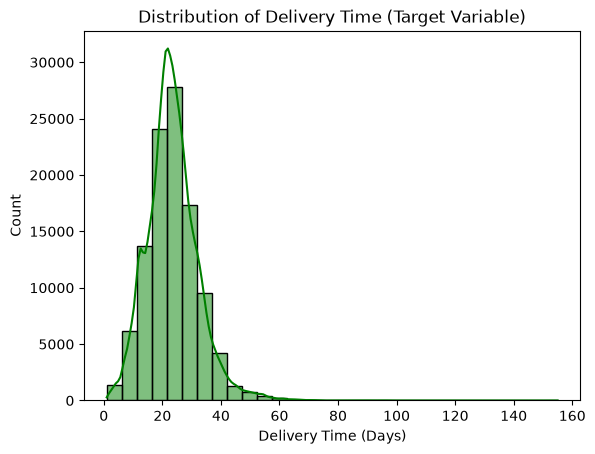

In [130]:
# Visualize the distribution of delivery time (target variable)
sns.histplot(df[target], kde=True, bins=30, color='green')
plt.xlabel('Delivery Time (Days)')
plt.title('Distribution of Delivery Time (Target Variable)')
plt.show()

In [131]:
df['delivery_time_days'].describe()

count    106994.000000
mean         23.480270
std           8.838746
min           1.000000
25%          18.000000
50%          23.000000
75%          28.000000
max         155.000000
Name: delivery_time_days, dtype: float64

It is entirely possible for a parcel to take 155 days

# Univariate Analysis

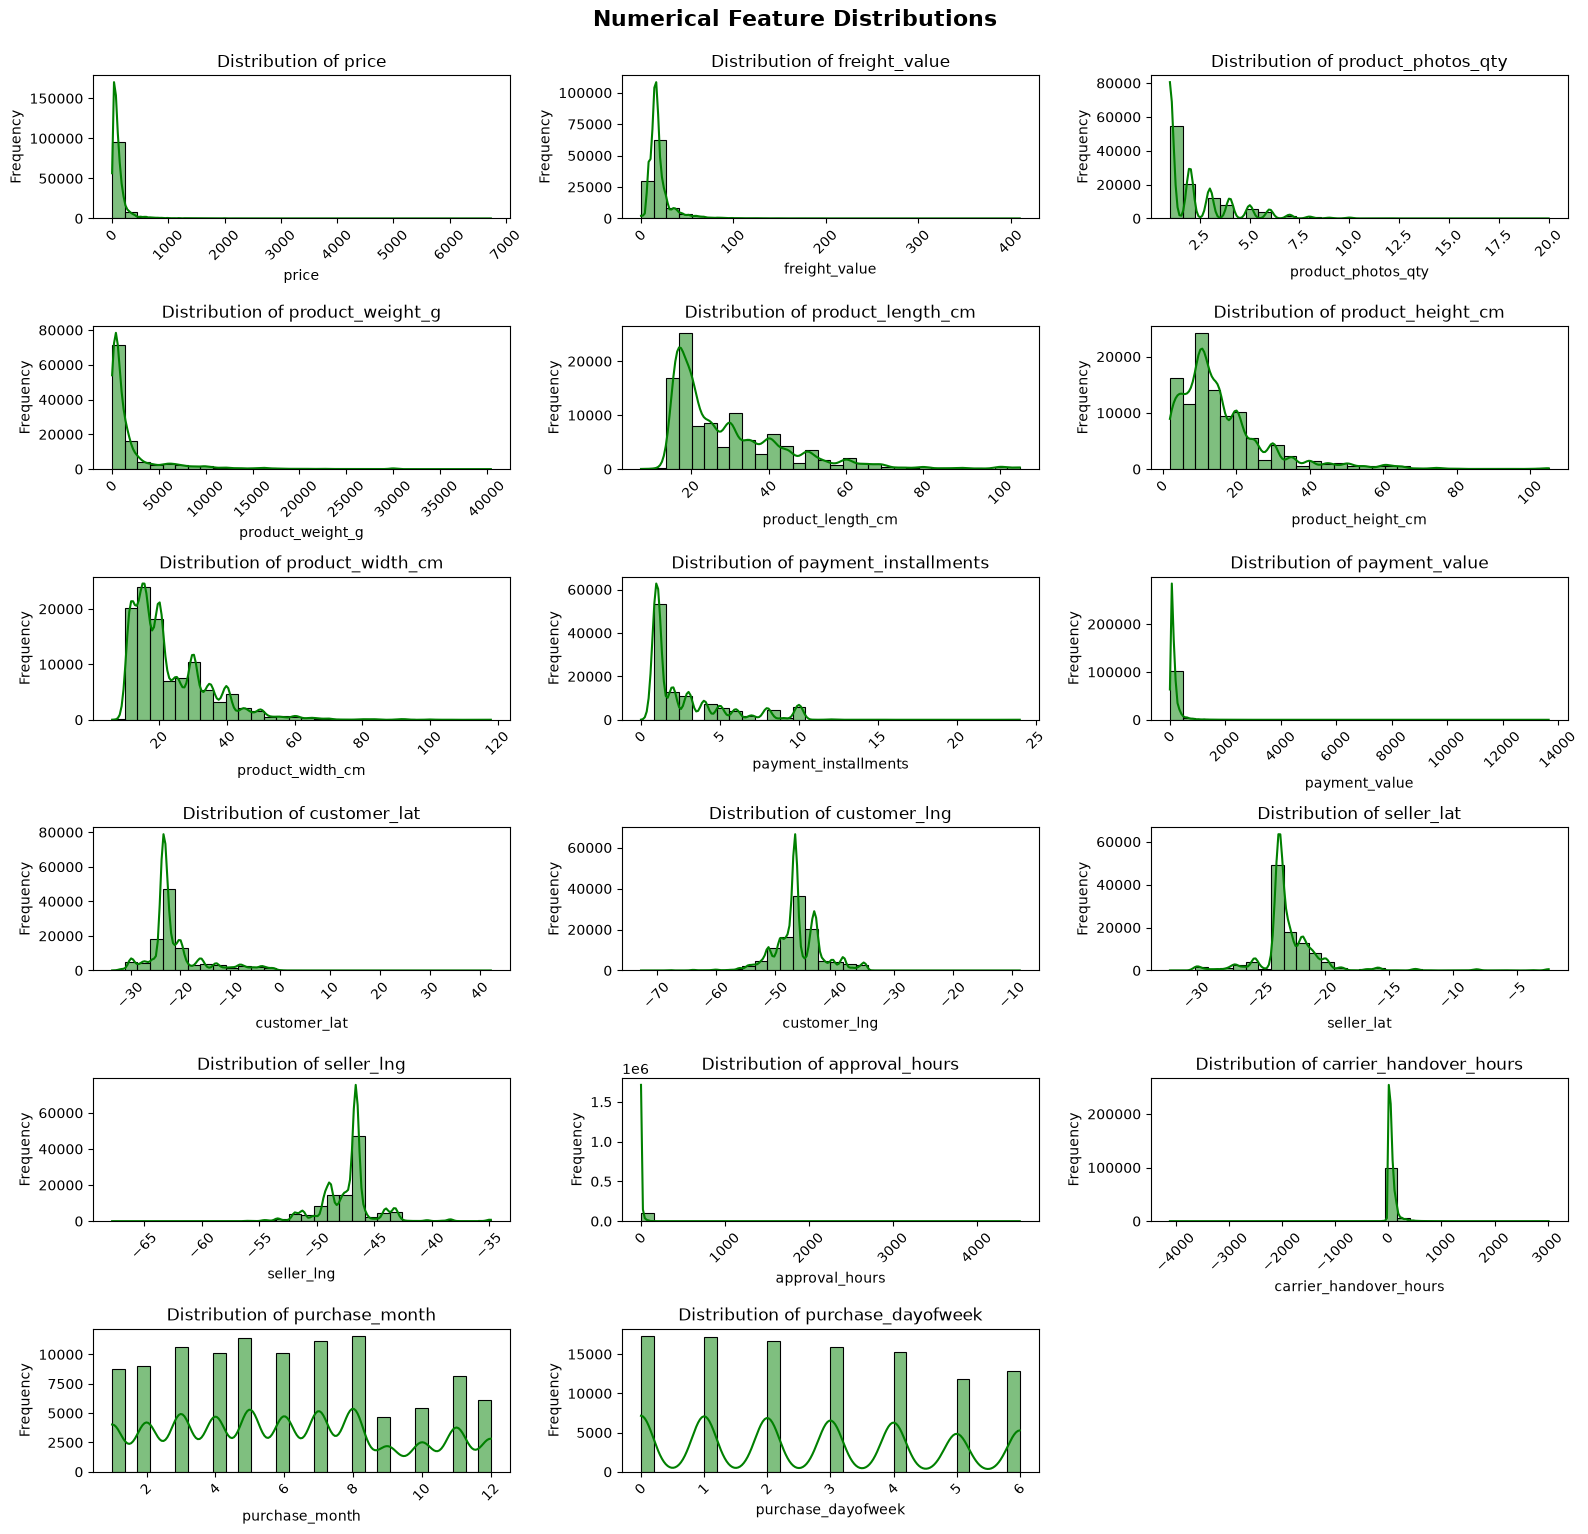

In [132]:
# Visualize the distribution of numerical features
plt.figure(figsize=(16, 15))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(6, 3, i)
    sns.histplot(data=df, x=feature, kde=True, color='green', bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Numerical Feature Distributions", fontsize=16, y=1.02, fontweight='bold')
plt.show()

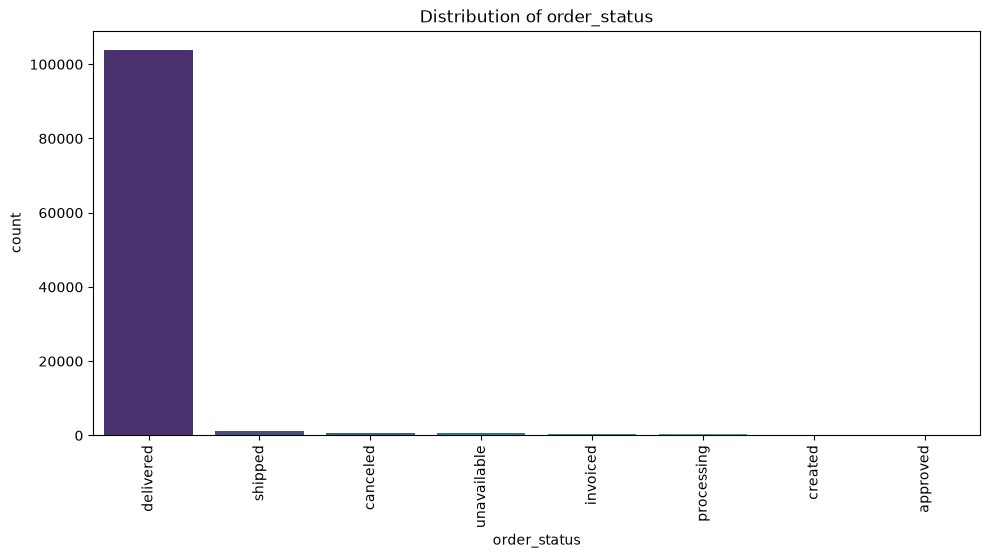

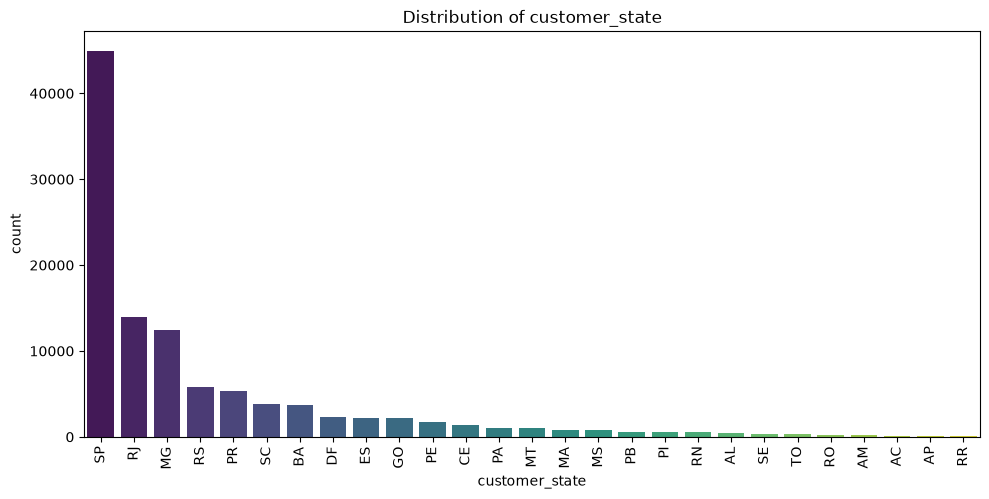

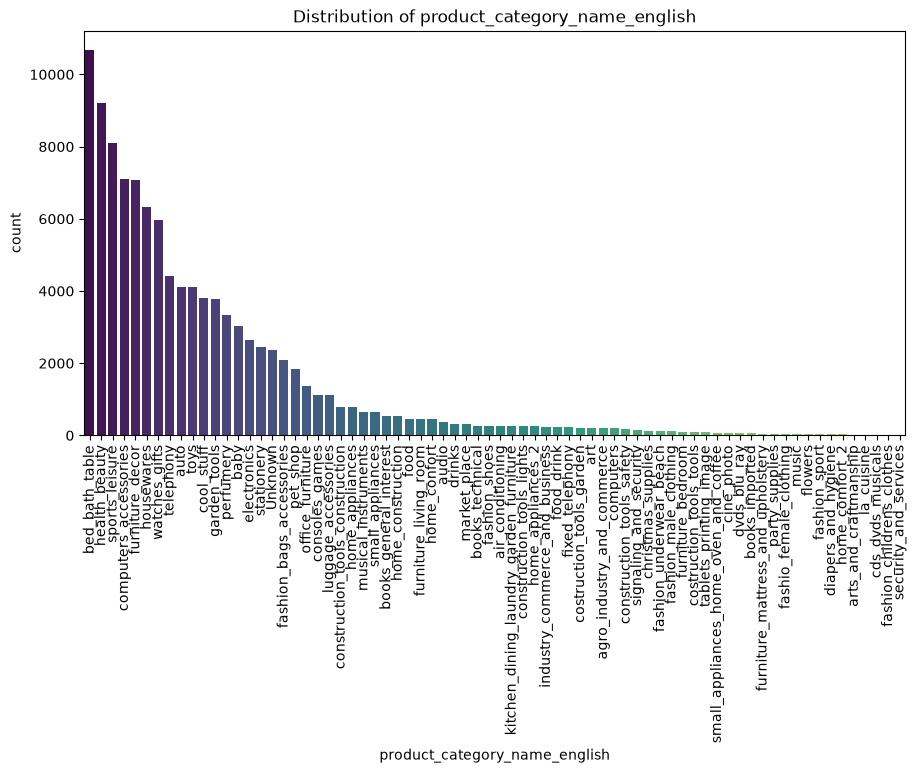

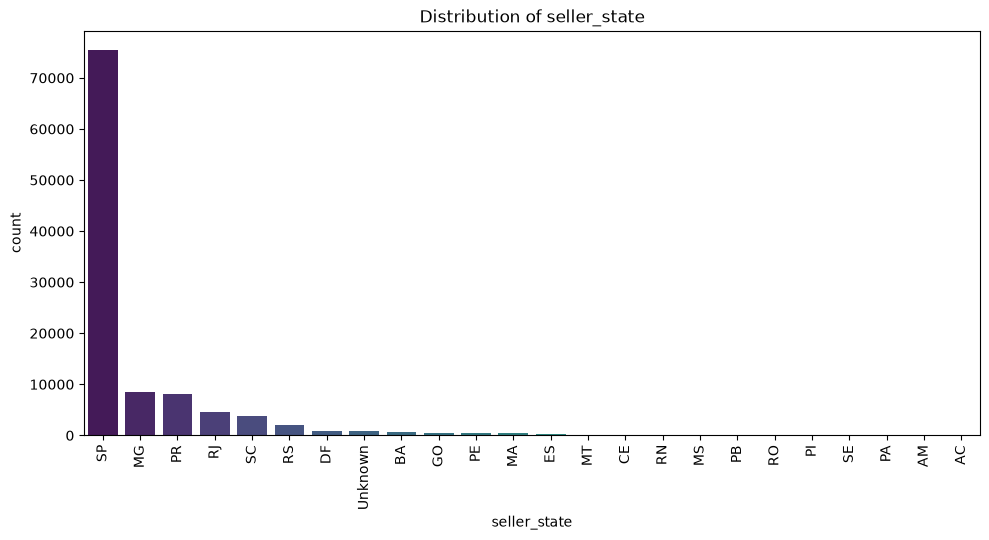

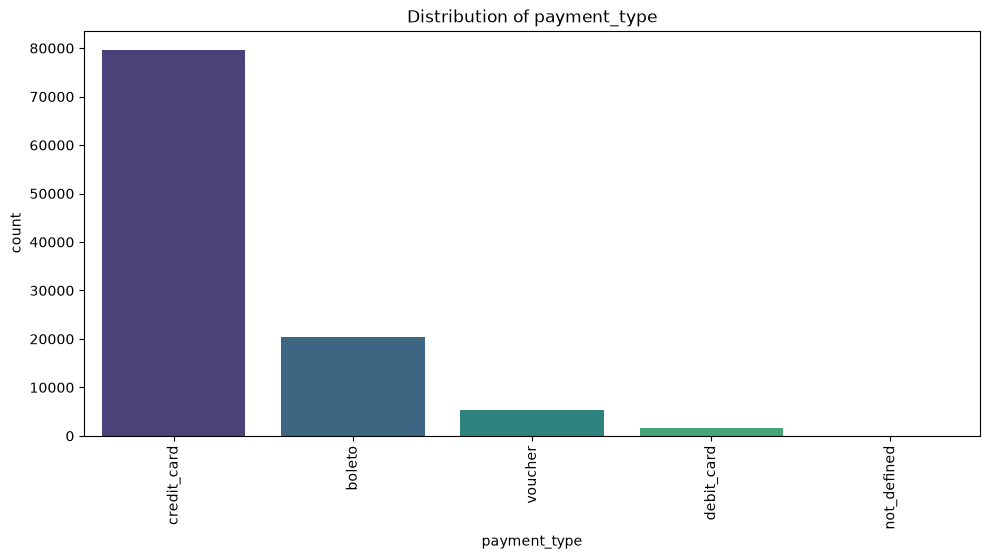

In [133]:
# Visualize the distribution of categorical features
for column in categorical_columns:
    plt.figure(figsize=(10,5))

    order = df[column].value_counts().index

    sns.countplot(data=df, x=column, order=order, palette='viridis')

    plt.title(f'Distribution of {column}')
    plt.tight_layout()
    plt.xticks(rotation=90)
    plt.show()

Which states have highest delivery times?

In [134]:
df.groupby('customer_state')['delivery_time_days'].mean().sort_values(ascending=False).head(1)

customer_state
RR    46.148936
Name: delivery_time_days, dtype: float64

Which product categories take longest?

In [135]:
df.groupby('product_category_name_english')['delivery_time_days'].mean().sort_values(ascending=False).head(1)

product_category_name_english
office_furniture    31.388807
Name: delivery_time_days, dtype: float64

# Bivariate Analysis

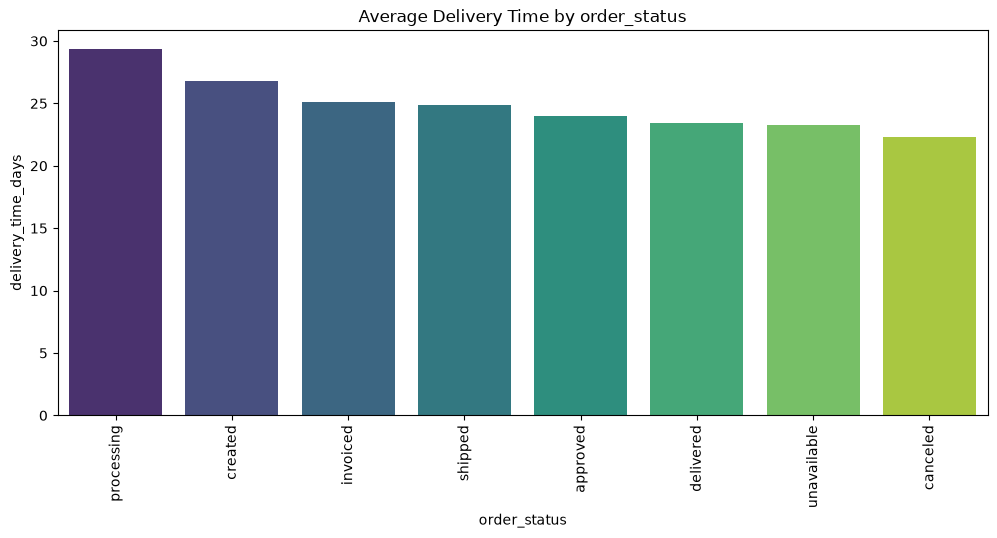

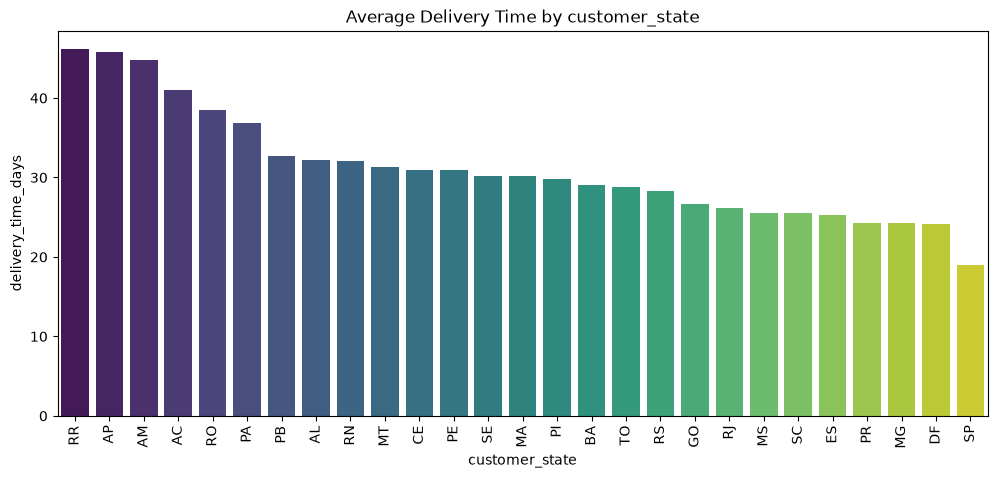

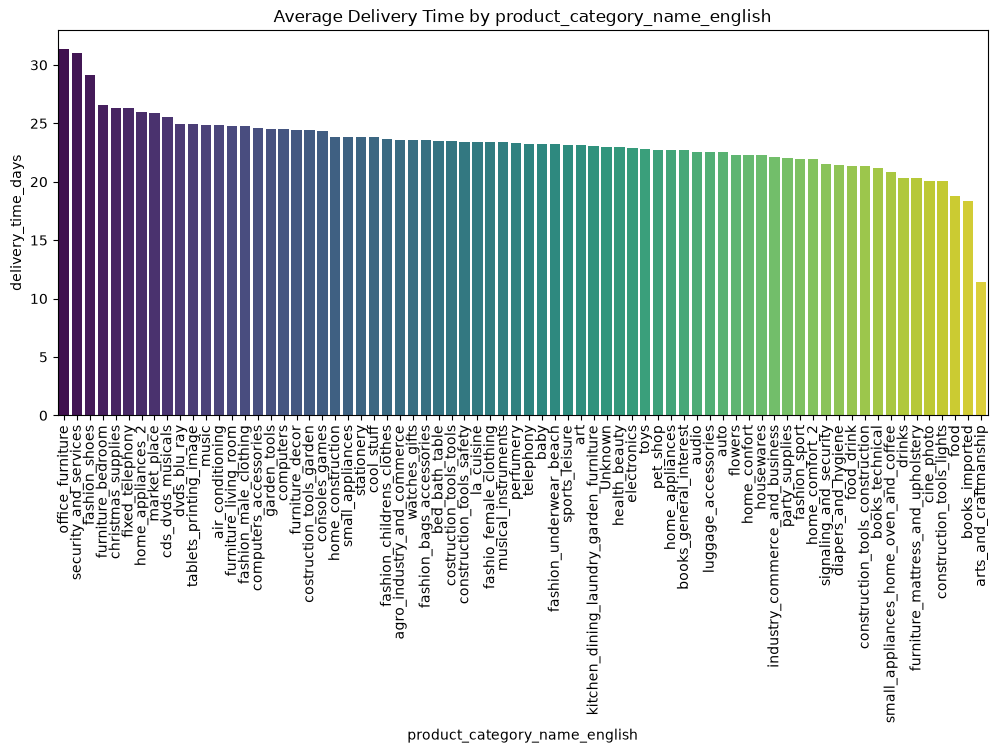

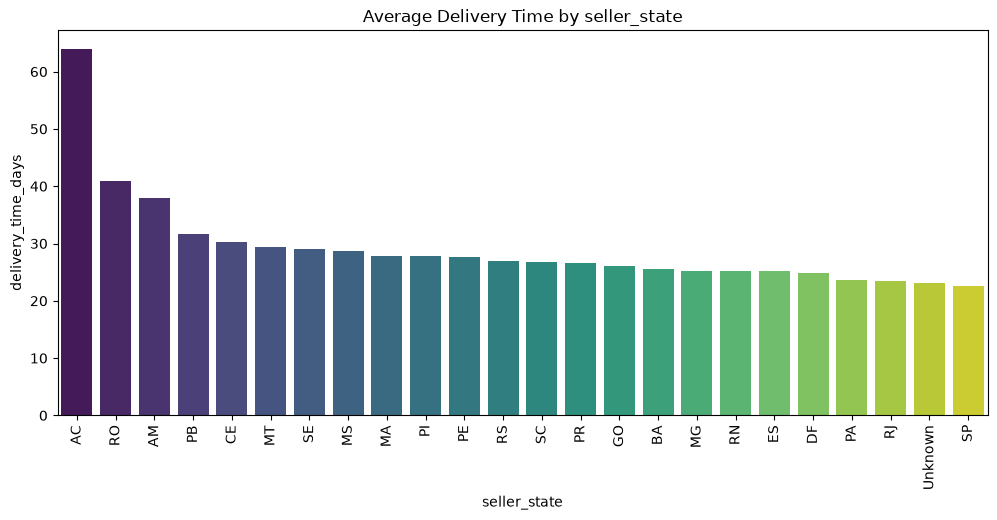

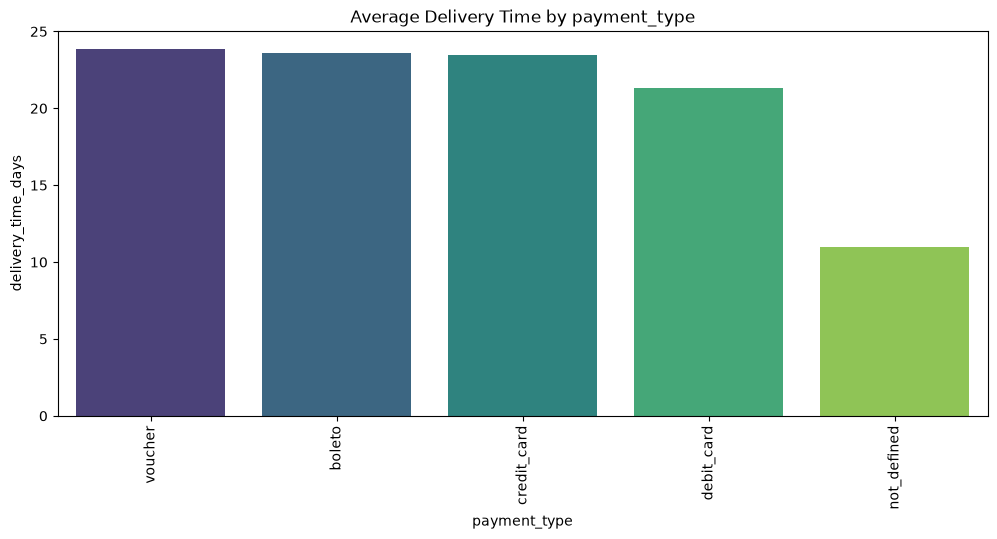

In [136]:
# Visualize the relationship between categorical features and the target variable
for column in categorical_columns:
    grouped = (df.groupby(column)['delivery_time_days'].mean().sort_values(ascending=False).reset_index())
    plt.figure(figsize=(12,5))
    sns.barplot(data=grouped, x=column, y=df[target].name, palette='viridis')
    plt.title(f'Average Delivery Time by {column}')
    plt.xticks(rotation=90)
    plt.show()

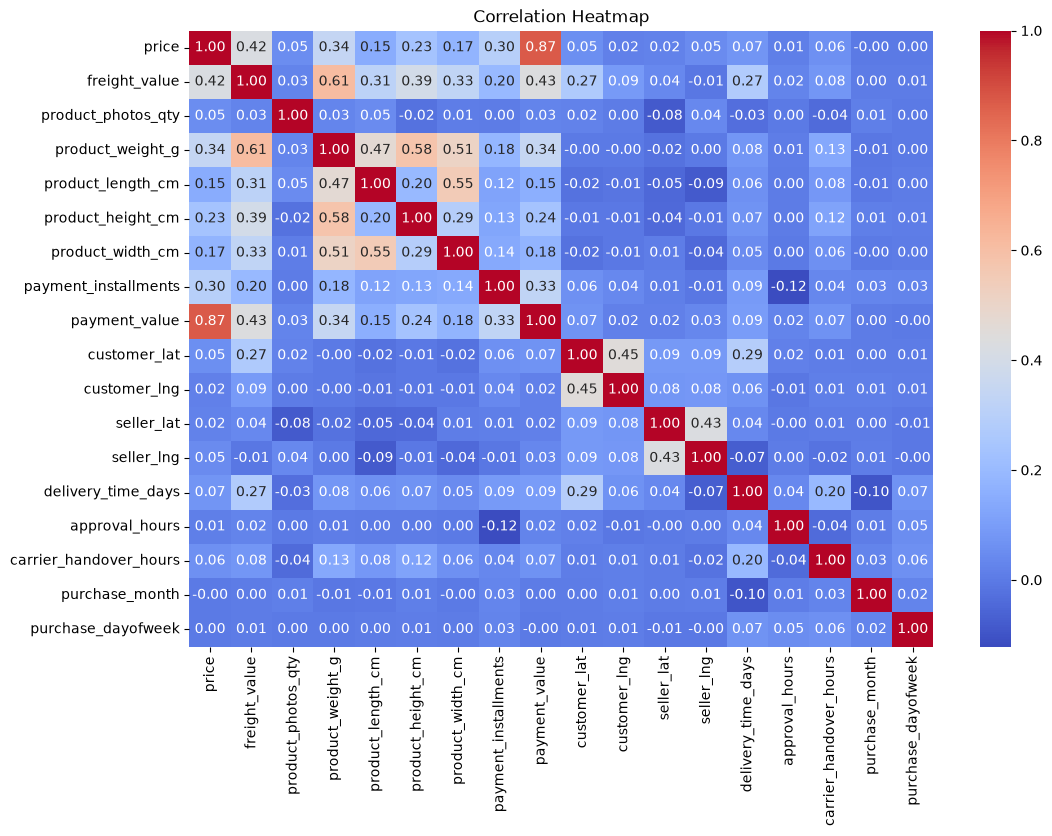

In [137]:
# Visualize the relationship between numerical features and the target variable
plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

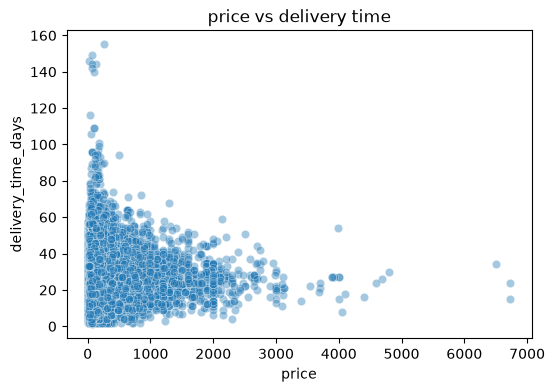

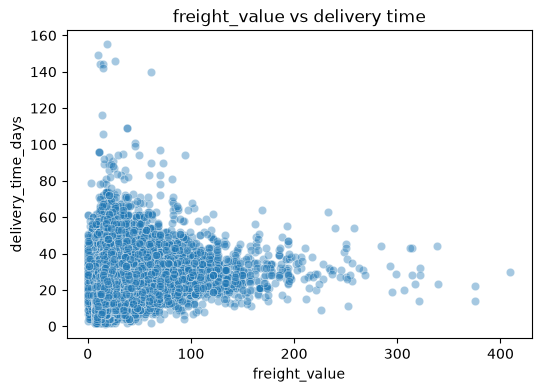

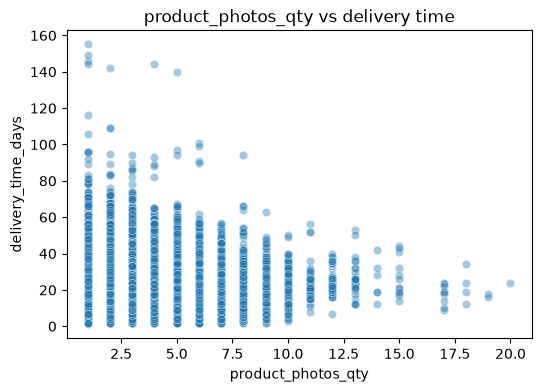

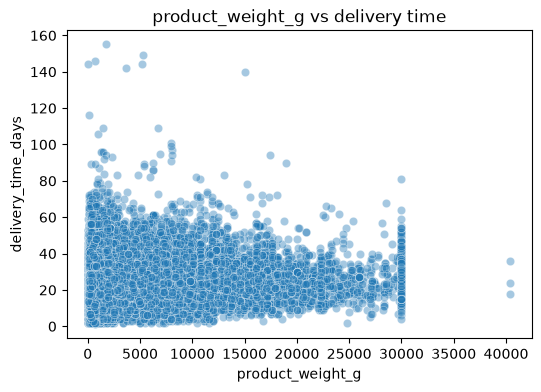

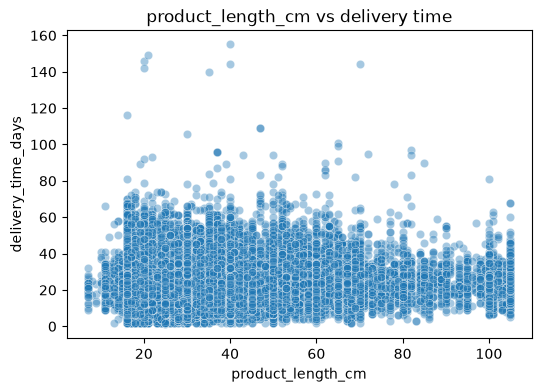

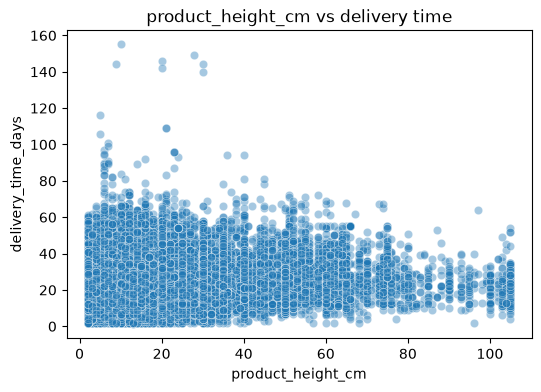

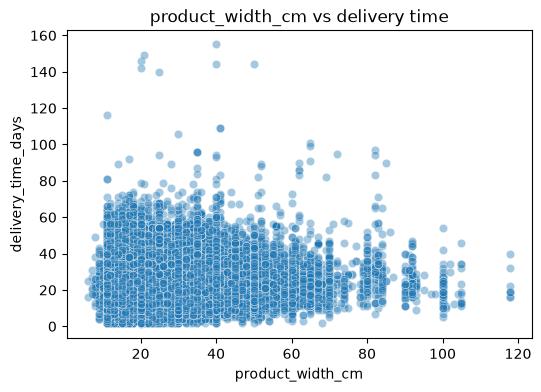

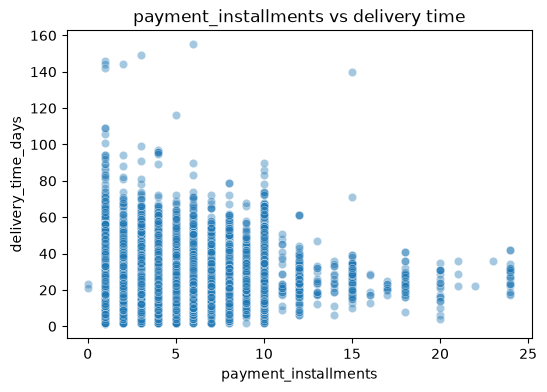

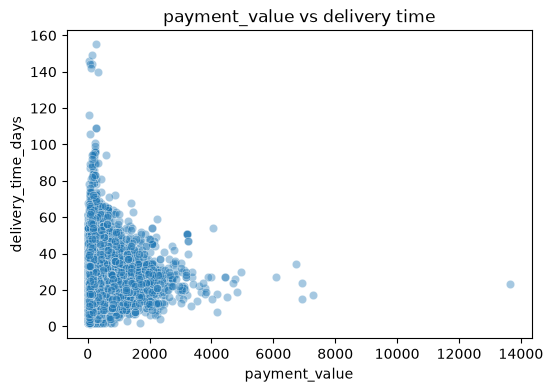

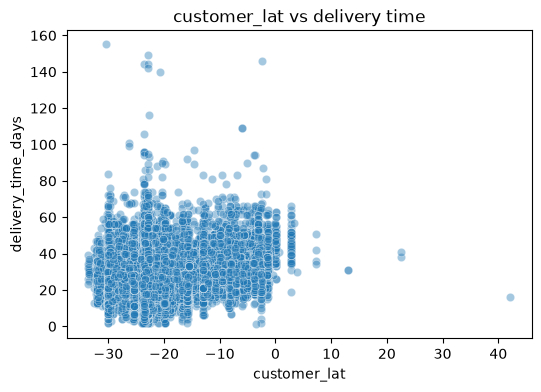

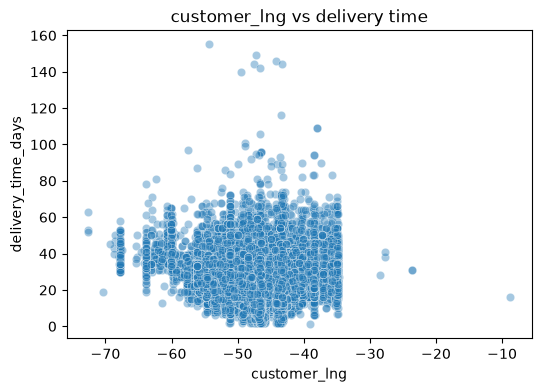

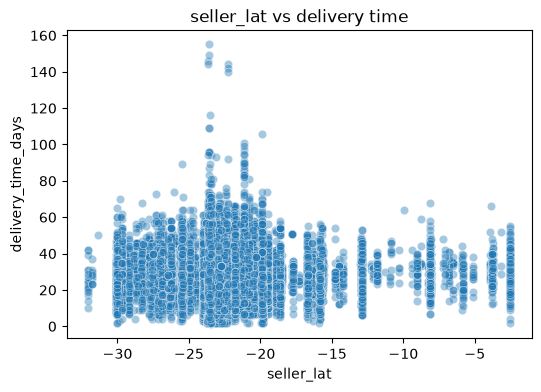

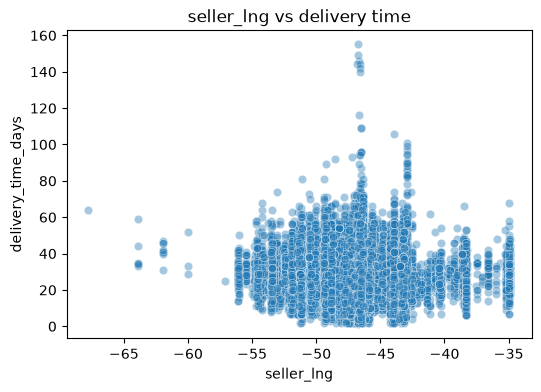

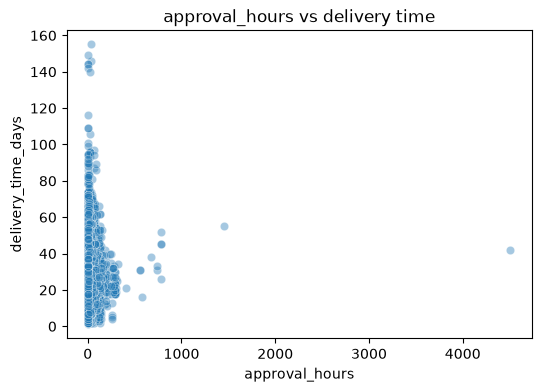

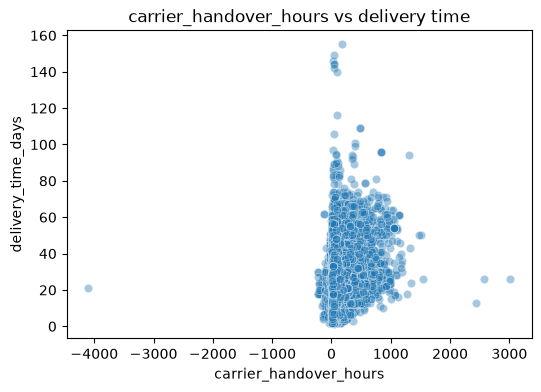

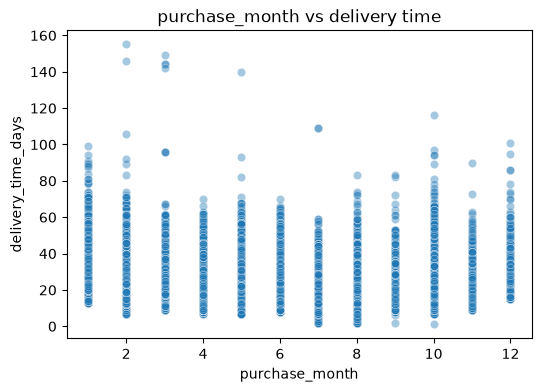

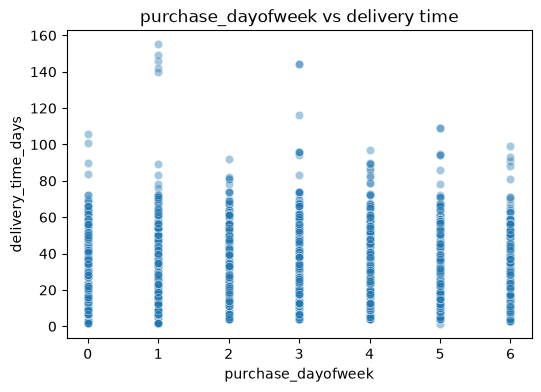

In [138]:
# Visualize the relationship between numerical features and the target variable
for column in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=column, y='delivery_time_days', alpha=0.4)
    plt.title(f'{column} vs delivery time')
    plt.show()

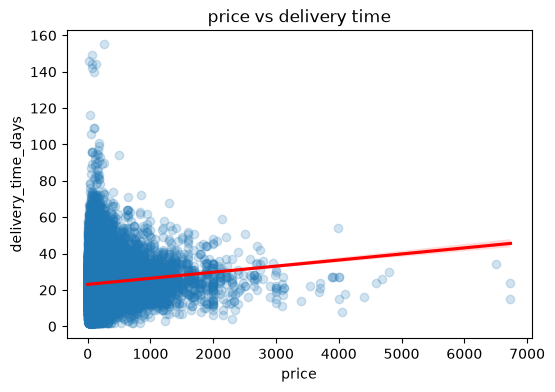

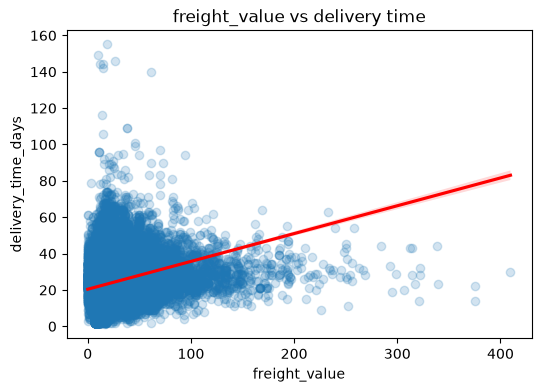

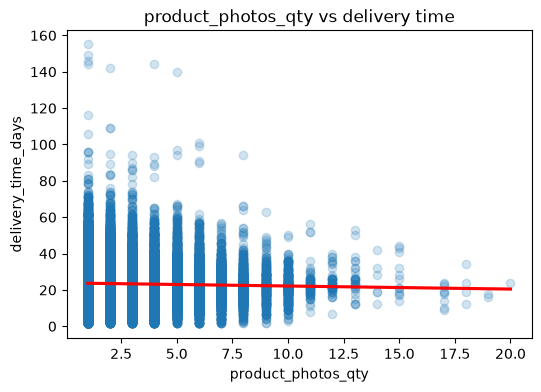

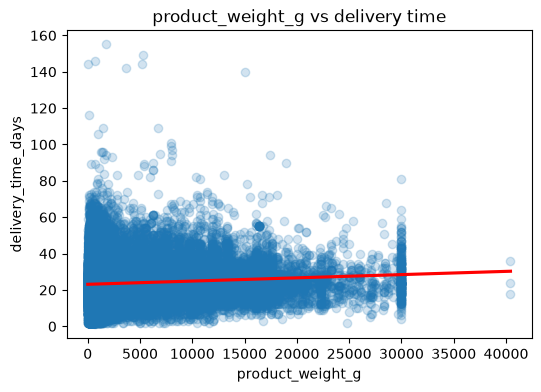

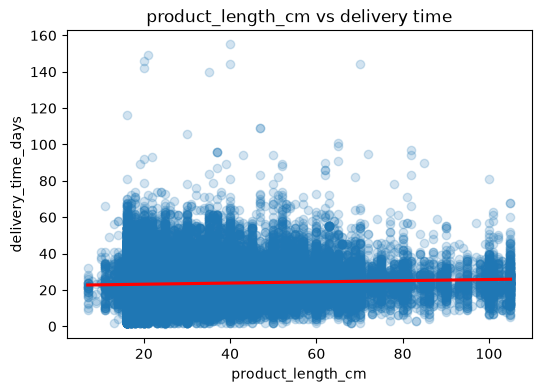

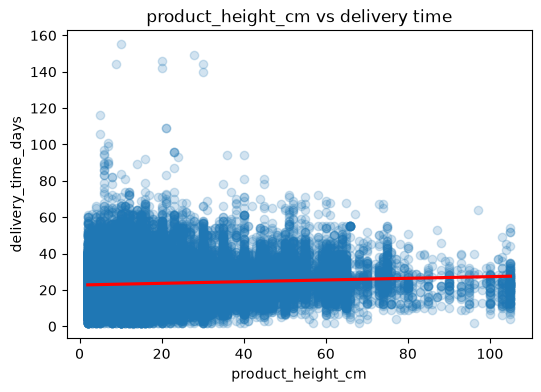

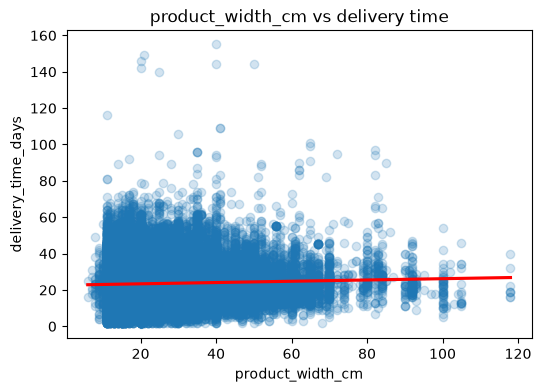

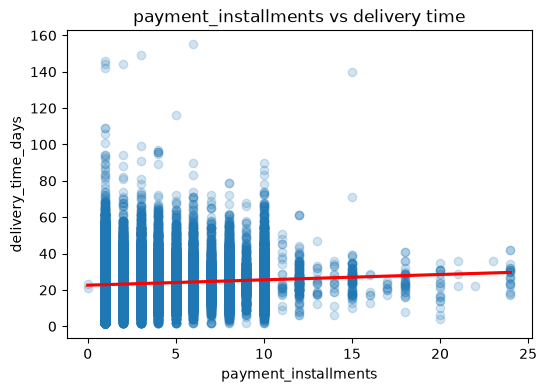

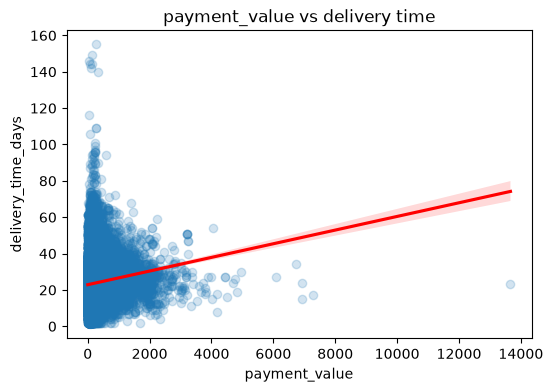

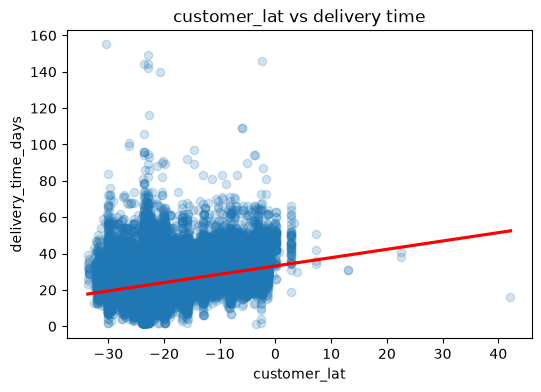

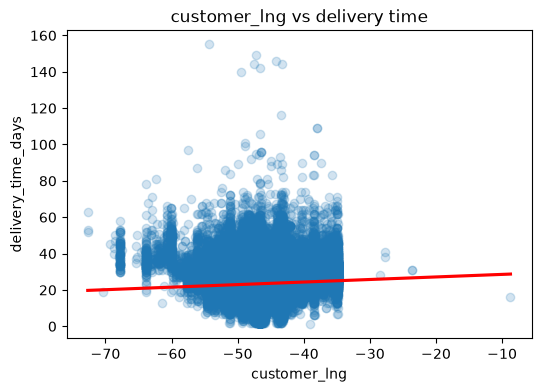

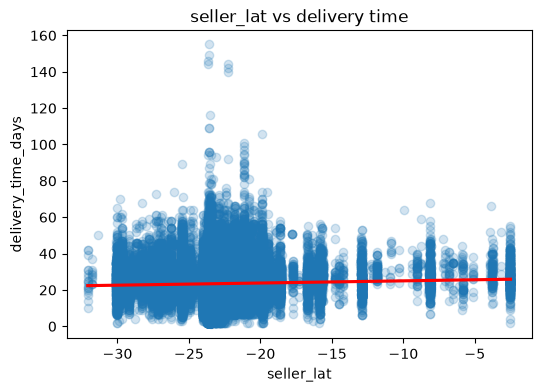

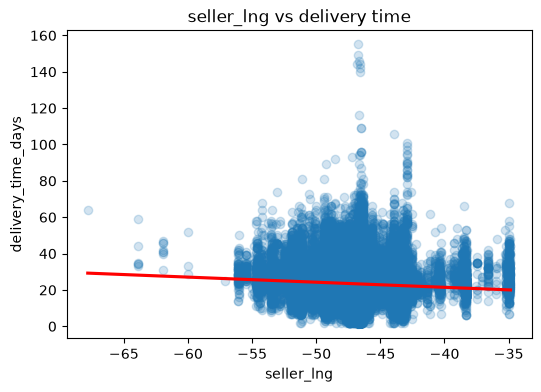

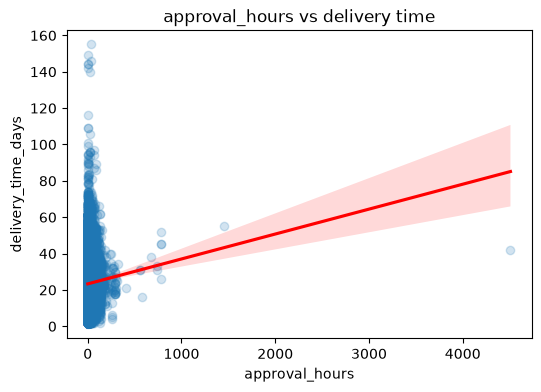

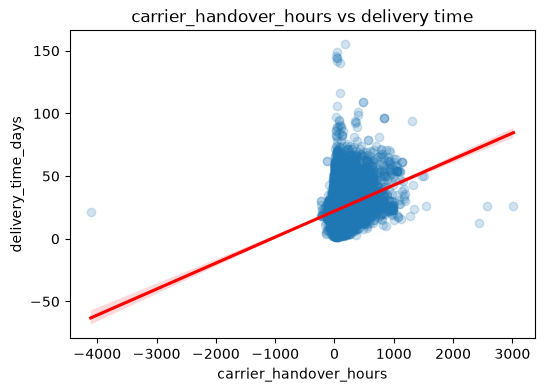

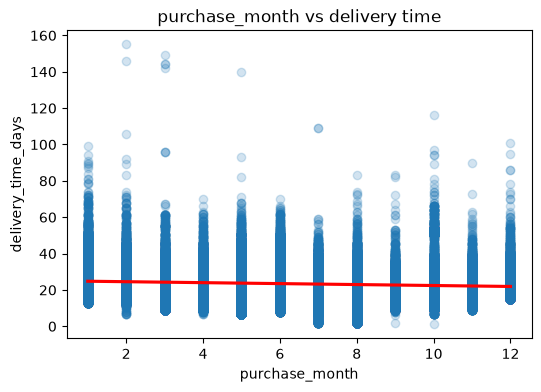

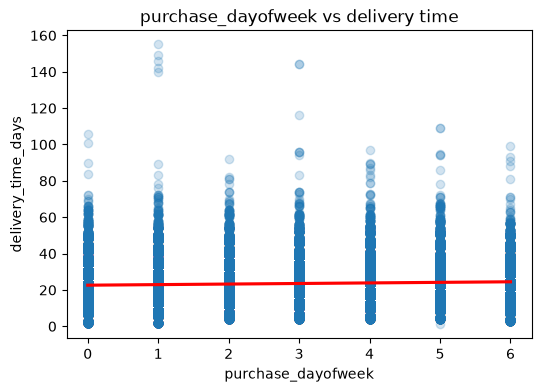

In [139]:
# Visualize the relationship between numerical features and the target variable using regression plots
for column in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.regplot(data=df, x=column,y='delivery_time_days', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
    plt.title(f'{column} vs delivery time')
    plt.show()

In [140]:
data = df.to_csv("../data/analysed_data.csv", index=False)